# 02 — Generative Model Comparison

## 📚 Learning Objectives

By completing this notebook, you will:
- Compare the three main deep generative families — **GANs**, **VAEs**, and **flow-based models** — on training objective, sample quality, diversity, speed, and likelihood
- Practice **selecting a model family** for a given use case with an explicit decision procedure

## 🔗 Where this fits

**Builds on:** Course 08 (AIAT 122) — Unit 4, lesson 01 "GANs and Autoencoders / VAEs", where these families were first met, and Course 10 — Unit 1, lesson 01: generative is now the chosen side, so the question is which family.

**Used later in:** Course 10 — Units 1-3, which implement each family in turn, and Unit 5, lesson 04, which compares their production descendants.

---

## Introduction

All generative models answer the same question — *"what does the data distribution look like, and can I sample from it?"* — but the three big families answer it very differently. This notebook is a **conceptual comparison and selection guide**; the hands-on implementations follow in example 04 (VAE) and example 05 (GAN).

---

## 🌍 Why this lesson exists — the family choice that decided the 2022 image-generation market

This selection decision was made for real, publicly, in 2022. Stability AI shipped **Stable Diffusion** as *latent diffusion* (Rombach et al., 2022, arXiv 2112.10752), not as a GAN, while NVIDIA's StyleGAN line stayed confined to narrow aligned domains such as faces. By 2026 essentially every production image and video generator descends from that diffusion lineage — transformer diffusion backbones (Peebles & Xie, 2022, arXiv 2212.09748) and flow matching (Lipman et al., 2022, arXiv 2210.02747) — not from the GAN lineage. Read the table below with that in mind: it is an accurate map of 2014–2021, and the family that won production is the one it does not list. Diffusion arrives in Unit 3, example 04.

**What goes wrong without this:** teams pick a family by folklore ("GANs are sharp") instead of by requirement. Three months later the training loop still will not converge, and someone finally states the real requirement — a likelihood, or a text prompt, or a 200 ms latency budget — that the chosen architecture cannot supply at any amount of tuning.


## The Three Families

**GAN (Generative Adversarial Network)** — a Generator is trained to fool a Discriminator (example 01 previewed this; example 05 builds it). No explicit probability model: you cannot ask a GAN "how likely is this image?". Samples tend to be **sharp** but training is unstable and can *mode-collapse* (produce only a few types of output).

**VAE (Variational Autoencoder)** — an encoder maps data to a latent Gaussian distribution, a decoder maps latent vectors back to data; trained by maximizing a lower bound (ELBO) on log-likelihood (example 04 builds one). Training is **stable** and the latent space is smooth and useful, but samples tend to be **blurrier** because of the pixel-wise reconstruction loss.

**Flow-based models** (RealNVP, Glow) — a chain of *invertible* transformations turns a simple Gaussian into the data distribution. Because every step is invertible, the model computes **exact log-likelihood** — the only family that can. The price: architectural restrictions (invertibility) and typically larger/slower models. Flows are not implemented in this course; see the references.


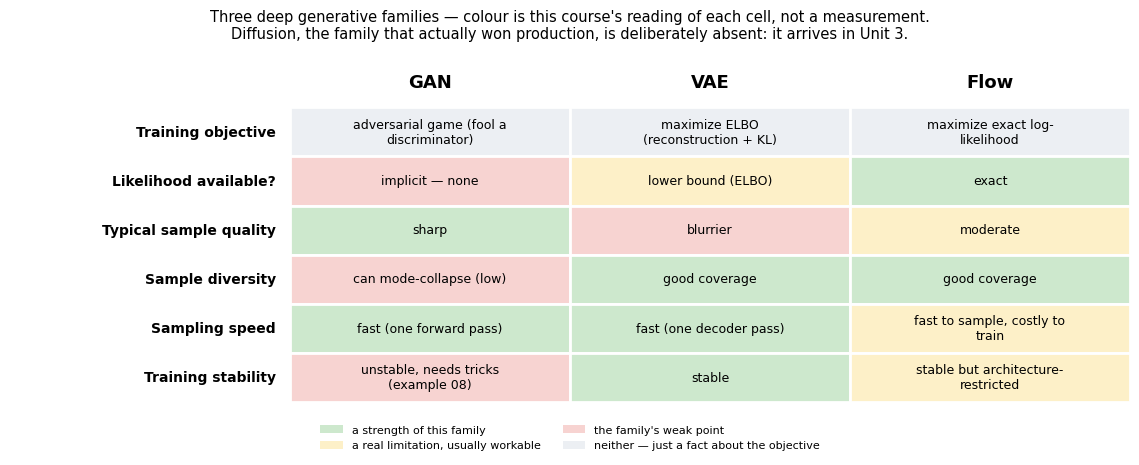

In [1]:
# WHAT/WHY: put the three families side by side in one comparison table.
# This is reference knowledge (from the papers cited below), organized so you
# can scan a row and see how the families differ on each property.
import pandas as pd

comparison = pd.DataFrame({
    "GAN":  ["adversarial game (fool a discriminator)", "implicit — none",
             "sharp", "can mode-collapse (low)", "fast (one forward pass)",
             "unstable, needs tricks (example 08)"],
    "VAE":  ["maximize ELBO (reconstruction + KL)", "lower bound (ELBO)",
             "blurrier", "good coverage", "fast (one decoder pass)",
             "stable"],
    "Flow": ["maximize exact log-likelihood", "exact",
             "moderate", "good coverage", "fast to sample, costly to train",
             "stable but architecture-restricted"],
}, index=["Training objective", "Likelihood available?", "Typical sample quality",
          "Sample diversity", "Sampling speed", "Training stability"])

# ── Draw the table instead of printing it, so a class can read it from the ──
# back of the room, and colour each cell by what it means for that family.
# The colour is THIS COURSE'S reading of the cell's own wording (a strength, a
# workable limitation, the weak point, or a neutral fact) — it is not a measured
# score, and the legend says so.
import textwrap
import matplotlib.pyplot as plt

TONE = {   # one tone per (row, family) — same order as the columns above
    "Training objective":     ["fact", "fact", "fact"],
    "Likelihood available?":  ["weak", "limit", "strength"],
    "Typical sample quality": ["strength", "weak", "limit"],
    "Sample diversity":       ["weak", "strength", "strength"],
    "Sampling speed":         ["strength", "strength", "limit"],
    "Training stability":     ["weak", "strength", "limit"],
}
COLOR = {"strength": "#cde8cd", "limit": "#fdf0c8", "weak": "#f7d3d1", "fact": "#eceff3"}
rows, cols = list(comparison.index), list(comparison.columns)

fig, ax = plt.subplots(figsize=(11.5, 4.8))
ax.set_xlim(0, 4); ax.set_ylim(0, len(rows) + 1); ax.invert_yaxis(); ax.axis("off")
for j, fam in enumerate(cols):                       # column headers
    ax.text(1.5 + j, 0.5, fam, ha="center", va="center", fontsize=13, fontweight="bold")
for i, prop in enumerate(rows):                      # row labels + coloured cells
    ax.text(0.95, i + 1.5, prop, ha="right", va="center", fontsize=10, fontweight="bold")
    for j, fam in enumerate(cols):
        ax.add_patch(plt.Rectangle((1 + j, i + 1), 1, 1,
                                   facecolor=COLOR[TONE[prop][j]], edgecolor="white", lw=2))
        ax.text(1.5 + j, i + 1.5, textwrap.fill(comparison.loc[prop, fam], 26),
                ha="center", va="center", fontsize=9)
keys = ["strength", "limit", "weak", "fact"]
labels = ["a strength of this family", "a real limitation, usually workable",
          "the family's weak point", "neither — just a fact about the objective"]
ax.legend([plt.Rectangle((0, 0), 1, 1, facecolor=COLOR[k]) for k in keys], labels,
          loc="lower center", bbox_to_anchor=(0.5, -0.17), ncol=2, fontsize=8, frameon=False)
ax.set_title("Three deep generative families — colour is this course's reading of each cell, not a measurement.\n"
             "Diffusion, the family that actually won production, is deliberately absent: it arrives in Unit 3.",
             fontsize=10.5, pad=14)
plt.tight_layout(); plt.show()


**Read the scorecard.** Scan a **row** to compare the families on one property; scan a **column** to see what one family is like to live with.

Only one row is a clean sweep for a single family: **likelihood**. Flow is the only green cell there, and that is why the decision procedure below checks it first — no amount of tuning gives a GAN an exact log-likelihood.

Read GAN's column top to bottom and you get the honest trade: green on sharpness and sampling speed, red on likelihood, diversity **and** stability. VAE's column is the mirror image — green on everything about the training experience, red only on sample quality. Nothing here says one family is better; each column is a different bill to pay.

The grey row at the top is deliberate: a training objective is not a strength or a weakness, it is the *cause* of everything coloured underneath it. The next cell shows exactly that for the sharp/blurry row.

## Why the Table Says "Sharp" and "Blurrier"

Two cells of that table get quoted more than all the others: **GAN — sharp**, **VAE — blurrier**. That difference is not a mysterious property of the architectures; it follows directly from what each objective *rewards*, and you can see it on real data without training anything.

Mean sharpness of the 200 individual real 3s : 0.0738
Sharpness of their pixel-wise average        : 0.0436   (59% of the real value)


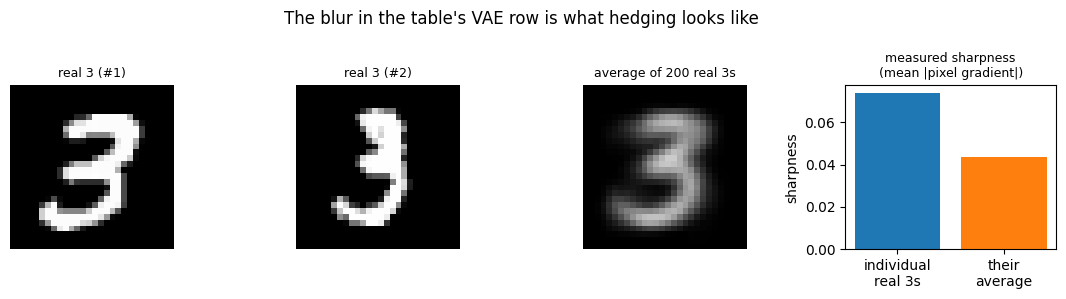


No model was trained here — this is the mechanism, not a VAE. Example 09
trains a real VAE and a real GAN on one dataset and measures the same
sharpness statistic on their samples.


In [2]:
# WHAT/WHY: demonstrate the MECHANISM behind the table's sample-quality row on
# real MNIST digits. A pixel-wise reconstruction loss (the VAE's) is minimised,
# when the model is unsure which exact digit it is facing, by outputting
# something close to the AVERAGE of the possibilities. An adversarial loss (the
# GAN's) gives no credit for that hedge — a discriminator rejects the average
# image immediately — so it forces the generator to commit to one sample.
import numpy as np
import matplotlib.pyplot as plt
import torchvision

# ── REAL DATA: handwritten 3s from MNIST (already in ./data from example 01) ──
ds     = torchvision.datasets.MNIST('./data/mnist', train=True, download=True)
imgs   = ds.data.numpy() / 255.0          # 60,000 real 28x28 digits, scaled to [0,1]
labels = ds.targets.numpy()
threes = imgs[labels == 3][:200]          # 200 real handwritten 3s
avg3   = threes.mean(axis=0)              # the pixel-wise average of those 200

# ── Sharpness = mean absolute pixel-to-pixel change (higher = sharper edges) ──
def sharpness(img):
    gx = np.abs(np.diff(img, axis=1)).mean()
    gy = np.abs(np.diff(img, axis=0)).mean()
    return (gx + gy) / 2

s_real = float(np.mean([sharpness(t) for t in threes]))
s_avg  = float(sharpness(avg3))
print(f"Mean sharpness of the 200 individual real 3s : {s_real:.4f}")
print(f"Sharpness of their pixel-wise average        : {s_avg:.4f}"
      f"   ({s_avg/s_real:.0%} of the real value)")

# ── One figure: two real 3s, their average, and the two sharpness numbers ────
fig, axes = plt.subplots(1, 4, figsize=(11, 3))
for ax, img, title in [(axes[0], threes[0], "real 3 (#1)"),
                       (axes[1], threes[1], "real 3 (#2)"),
                       (axes[2], avg3,      "average of 200 real 3s")]:
    ax.imshow(img, cmap='gray', vmin=0, vmax=1); ax.axis('off')
    ax.set_title(title, fontsize=9)
axes[3].bar(["individual\nreal 3s", "their\naverage"], [s_real, s_avg],
            color=["tab:blue", "tab:orange"])
axes[3].set_title("measured sharpness\n(mean |pixel gradient|)", fontsize=9)
axes[3].set_ylabel("sharpness")
plt.suptitle("The blur in the table's VAE row is what hedging looks like")
plt.tight_layout(); plt.show()

print("\nNo model was trained here — this is the mechanism, not a VAE. Example 09")
print("trains a real VAE and a real GAN on one dataset and measures the same")
print("sharpness statistic on their samples.")

**Read the figure.** The first two panels are genuine handwritten 3s: crisp strokes, sharp edges, and clearly *different* from each other. The third panel is their pixel-wise average — still recognisably a 3, but soft-edged and belonging to nobody. The bar chart puts a number on that difference: the average image measures a fraction of the sharpness of the individual digits it was built from.

That third panel is the **best possible answer under a pixel-wise loss when the model is uncertain**. Squared or per-pixel cross-entropy error is minimised in expectation by predicting the mean of the plausible outputs, so a VAE that is unsure which 3 it should produce is actively rewarded for producing the blur — hence the table's *"VAE — blurrier"*.

An adversarial objective scores differently: a discriminator has never seen a real digit that looks like the third panel, so it labels it fake at once and the generator gets punished for hedging. It must **commit** to one sharp sample — hence *"GAN — sharp"*. The same pressure explains the row underneath: committing to whatever fools the discriminator is also what lets a GAN quietly stop covering the modes it finds hard, which is the *"can mode-collapse"* cell.

In [3]:
# WHAT/WHY: turn the table into an explicit decision procedure — a small
# rule-based function that recommends a model family from a use case's
# requirements, then run it on three realistic scenarios.

def recommend_family(needs_exact_likelihood, needs_sharpest_samples, needs_easy_training):
    """Pick a generative family from three yes/no requirements (simplified guide)."""
    # Exact likelihood is the deciding requirement: only flows provide it.
    if needs_exact_likelihood:
        return "Flow", "only flow models give exact log-likelihood"
    # Next priority: photorealistic sharpness points to GANs.
    if needs_sharpest_samples and not needs_easy_training:
        return "GAN", "adversarial training yields the sharpest samples (at the cost of stability)"
    # Otherwise the stable, general-purpose default is the VAE.
    return "VAE", "stable training, smooth latent space, good-enough samples"

scenarios = [
    ("Density estimation / anomaly scoring for fraud detection",
     dict(needs_exact_likelihood=True,  needs_sharpest_samples=False, needs_easy_training=True)),
    ("Photorealistic face generation for a game studio",
     dict(needs_exact_likelihood=False, needs_sharpest_samples=True,  needs_easy_training=False)),
    ("Latent-space data exploration + controllable generation, small team",
     dict(needs_exact_likelihood=False, needs_sharpest_samples=False, needs_easy_training=True)),
]

# Apply the rules to each scenario and print the computed recommendation
for name, reqs in scenarios:
    family, reason = recommend_family(**reqs)
    print(f"Use case: {name}")
    print(f"  → Recommended family: {family}  (why: {reason})\n")


Use case: Density estimation / anomaly scoring for fraud detection
  → Recommended family: Flow  (why: only flow models give exact log-likelihood)

Use case: Photorealistic face generation for a game studio
  → Recommended family: GAN  (why: adversarial training yields the sharpest samples (at the cost of stability))

Use case: Latent-space data exploration + controllable generation, small team
  → Recommended family: VAE  (why: stable training, smooth latent space, good-enough samples)



## 💬 Discuss

1. Re-run the three scenarios in your head with **diffusion** added as a fourth option. Which recommendations change, and which line of `recommend_family` would you have to rewrite first? What requirement would you need to add to the function signature?
2. The rule checks `needs_exact_likelihood` first and returns Flow immediately. Is that the right priority for fraud scoring, where you also have to score ten thousand transactions a second? Reorder the checks and justify the new order.
3. The table's cell "GAN — sample diversity: can mode-collapse (low)" is a claim from the literature, not a measurement in this notebook. Which printed number in example 08 or example 09 would you point at to support it — and which one arguably contradicts it?


## Where You Will Build Them

- **GAN** — previewed in example 01; built step by step in **example 05**; stabilized in **example 08**; compared head-to-head with a VAE in **example 09**.
- **VAE** — built in **example 04**; latent-space exploration in **example 12**; applied in depth in Unit 3.
- **Flow models** — concept-level only in this course; start with the Glow paper below if you want to go further.


## ⚠️ Where this breaks

**Family-level tables are decision aids, not evidence.** Lucic et al. (2018, arXiv 1711.10337) trained the major GAN variants under a matched computational budget and reported no evidence that any of them consistently outperformed the original non-saturating GAN. Differences that look architectural in a table often turn out to be tuning and compute in a controlled comparison.

**The rows that usually decide are missing.** There is no row for training compute, data volume, latency, or licence. A team with 5,000 images and one GPU is not really choosing between families at all — the correct answer is to fine-tune an open checkpoint, which this table cannot recommend because it does not model "someone else already trained it".

**The table stops in 2021.** A 2026 selection guide that offers only GAN / VAE / flow will send you to the wrong architecture for image, audio and video work. Use it to understand *what the three objectives buy you*; do not use it as a procurement checklist.


---

## 🔭 State of the field (2026)

*Enrichment, not examinable content — the official unit examines the technique above exactly as it is taught. This box says where that technique sits on the 2026 map.*

The scorecard above has a fourth column in 2026, and it is the one production uses: **diffusion, and its
continuous-time formulation, flow matching**. Flow matching trains a network to regress a velocity field that
transports noise to data along a chosen probability path (Lipman *et al.* 2022); the *rectified flow* variant
makes that path a straight line, and pairing it with a transformer backbone is the recipe behind the current
open text-to-image models (Esser *et al.* 2024). It never plays a min-max game — the objective is a regression,
so there is no critic to balance — and it still produces samples sharp enough that it displaced GANs as the
default for images and video.

**Why the three families below are still exactly the right thing to learn.** They are where every property in
your table comes from, and the fourth family is defined against them: an *implicit* sampler with no likelihood
(GAN), an *explicit* variational bound (VAE), an *exact* invertible density (flow). You cannot read the flow
matching paper without the change-of-variables argument you met in the flow row, and you cannot read a latent
diffusion paper without the VAE row. The 💬 Discuss prompt above already asks you to re-run the three scenarios
with diffusion as a fourth option — the two readings below are how to do it.

**Read:** Lipman *et al.* (2022), <https://arxiv.org/abs/2210.02747> · Esser *et al.* (2024),
<https://arxiv.org/abs/2403.03206> (both listed below).

---

## 📚 References & Further Reading

**Foundational Papers:**
- Goodfellow et al. (2014) — [Generative Adversarial Nets](https://arxiv.org/abs/1406.2661)
- Kingma & Welling (2014) — [Auto-Encoding Variational Bayes (VAE)](https://arxiv.org/abs/1312.6114)
- Dinh et al. (2017) — [RealNVP: Density Estimation Using Real NVP](https://arxiv.org/abs/1605.08803)
- Kingma & Dhariwal (2018) — [Glow: Generative Flow with Invertible 1×1 Convolutions](https://arxiv.org/abs/1807.03039)

**Survey:**
- Bond-Taylor et al. (2021) — [Deep Generative Modelling: A Comparative Review](https://arxiv.org/abs/2103.04922)

**The Fourth Family (add it to the table yourself — see 💬 Discuss above):**
- Lipman et al. (2022) — [Flow Matching for Generative Modeling](https://arxiv.org/abs/2210.02747) *(simulation-free training of continuous normalizing flows — the formulation behind current generators)*
- Lipman et al. (2024) — [Flow Matching Guide and Code](https://arxiv.org/abs/2412.06264) *(the self-contained review: mathematical foundations, design choices, extensions)*
- Esser et al. (2024) — [Scaling Rectified Flow Transformers for High-Resolution Image Synthesis](https://arxiv.org/abs/2403.03206) *(rectified flow — noise to data in a straight line — with a transformer backbone; the recipe behind current open text-to-image models)*


## 📝 Summary

In this notebook you compared the **three deep generative families**: GANs (adversarial, sharp, unstable, no likelihood), VAEs (ELBO, stable, smooth latents, blurrier), and flows (exact likelihood, restricted architectures). You also applied an explicit decision procedure to three realistic use cases. The hands-on builds come next: VAE in example 04, GAN in example 05.
